# Mangle spectra

In [1]:
import os
#COCO_PATH=os.environ['COCO_PATH']
COCO_PATH="/Users/ravkaur/Desktop/research/kilonova-SED/PyCoCo_templates/"
DATALC_PATH = COCO_PATH+"/Inputs/Photometry/4_LCs_late_extrapolated/"
DATASPEC_PATH = COCO_PATH+"/Inputs/Spectroscopy/"

DATAINFO_PATH= COCO_PATH+"Inputs/SNe_Info/"
FILTER_PATH = COCO_PATH+"Inputs/Filters/"

OUTPUT_DIR = COCO_PATH+"Outputs/"

import sys
sys.path.insert(0, COCO_PATH+'what_the_flux/')
import what_the_flux as wtf

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from astropy.io import fits
from scipy import interpolate
from scipy import integrate
import scipy.optimize as opt
import json

import george
from george.kernels import ExpSquaredKernel, ConstantKernel, Matern32Kernel

import matplotlib.cm as cm
import scipy
%matplotlib inline

In [3]:
color_dict = {'Bessell_U': 'blue', 'Bessell_B': 'royalblue','Bessell_V':  'limegreen',
              'Bessell_R':  'red', 'Bessell_I':  'mediumvioletred',
              'sdss_g':'darkgreen','ptf_g':'darkgreen', "sdss_g'":'darkgreen','sdss_i':'indianred',
              "sdss_i'":'indianred','sdss_r': 'darkred', "sdss_r'":'darkred','sdss_z':'sienna', "sdss_z'":'sienna',
              'sdss_u': 'darkblue', "sdss_u'": 'darkblue', 'Y':'salmon','H':'darkred', 'J':  'k',
              'Ks':  'brown','K':  'brown', 'swift_UVW1':'indigo', 'swift_UVW2':'darkblue',
               'swift_UVM2':'darkmagenta','swift_U':'plum','swift_V':'teal','swift_B':'powderblue'}

mark_dict = {'Bessell_U': 'o','Bessell_B': 'o', 'Bessell_V':'o', 'Bessell_R':'o', 'Bessell_I': 'o', 
             'sdss_g':'s','ptf_g':'s', "sdss_g'":'s', 'sdss_i':'s', "sdss_i'":'s',
                'sdss_r':'s', "sdss_r'":'s', 'sdss_z':'s', "sdss_z'":'s', 'sdss_u': 's', "sdss_u'": 's',
                'Y':  'o','H':  'o', 'J':  'o', 'Ks':  'o','K':  'o',
                'swift_UVW1':'D', 'swift_UVW2':'D', 'swift_UVM2':'D', 'swift_U':'D',
                'swift_V':'D', 'swift_B':'D'}

CSP_SNe = ['SN2004fe', 'SN2005bf', 'SN2006V', 'SN2007C', 'SN2007Y',
           'SN2009bb',  'SN2008aq', 'SN2006T', 'SN2004gq', 'SN2004gt',
           'SN2004gv','SN2006ep', 'SN2008fq', 'SN2006aa']

#exclude_filt = ['H', 'J', 'K', 'Ks','KS', 'Y']
#exclude_filt = ['KS']

In [4]:
color_dict = {
    # Existing matches from your example
    'Swope_i': 'indianred',
    'FourStar_H': 'darkred',
    'FourStar_J': 'black',
    'DECam_i': 'orangered',
    'DECam_z': 'darkslategray',
    'DECam_Y': 'goldenrod',
    'FourStar_Ks': 'brown',
    'UVOT_U': 'teal',
    'Skymapper_i': 'slateblue',
    'Sinistro_g': 'darkgreen',
    'Sinistro_r': 'crimson',
    'Skymapper_r': 'deeppink',
    'Skymapper_g': 'forestgreen',
    'EFOSC2_V': 'limegreen',
    'Sinistro_i': 'firebrick',
    'DECam_r': 'darkorange',
    'DECam_g': 'mediumspringgreen',
    'DECam_u': 'navy',
    'Swope_V': 'green',
    'FourStar_J1': 'dimgray',
    'Swope_B': 'royalblue',
    'Swope_r': 'red',
    'Swope_g': 'darkseagreen',
    'EFOSC2_U': 'blue',
    'Sinistro_V': 'mediumaquamarine',
    'Sinistro_z': 'sienna',
    'IMACS_r': 'darkred',
    'LRIS_I': 'mediumvioletred',
    'SOFI_H': 'firebrick',
    'SOFI_Ks': 'saddlebrown',

    # New assignments (color-coded by band)
    'VISTA_Ks': 'saddlebrown',
    'VISTA_J': 'dimgray',
    'VISTA_Y': 'salmon',
    'FLAMINGOS-2_Ks': 'sienna',
    'UVOT_M2': 'darkviolet',
    'UVOT_W1': 'purple',
    'UVOT_W2': 'indigo',
    'HSC_z': 'darkslategray',
    'GFC_i': 'firebrick',
    'GFC_y': 'goldenrod',
    'GFC_z': 'maroon',
    'GFC_r': 'tomato',
    'SIRIUS_H': 'darkred',
    'SIRIUS_J': 'black',
    'SIRIUS_Ks': 'brown',
    'T80Cam_g': 'seagreen',
    'GROND_H': 'maroon',
    'GROND_J': 'dimgray',
    'GROND_K': 'saddlebrown',
    'GROND_g': 'mediumseagreen',
    'GROND_i': 'orangered',
    'GROND_r': 'crimson',
    'GROND_z': 'darkslategray',
    'DECam_Y': 'goldenrod',
    'FLAMINGOS-2_H': 'firebrick',
    'IMACS_i': 'orangered',
    'FLAMINGOS-2_J': 'black',
    'UVOT_B': 'dodgerblue',
    'GMOS_g': 'green',
    'GMOS_i': 'indianred',
    'GMOS_r': 'red',
    'GMOS_z': 'darkslategray',
    'FORS2_R': 'crimson',
    'VIMOS_z': 'maroon',
    'FORS2_I': 'mediumvioletred',
    'FORS2_B': 'blue',
    'FORS2_V': 'limegreen',
    'ANDICAM_K': 'brown',
    'MOIRCS_Ks': 'sienna',
    'HAWKI_Ks': 'brown'
}

exclude_filt = []
#exclude_filt = ['H', 'J', 'K', 'Ks','KS', 'Y', 'FourStar_H', 'FourStar_J', 'FourStar_Ks', 'FourStar_J1',
#                'RetroCam_Y', 'RetroCam_H', 'RetroCam_J', 'SOFI_H', 'SOFI_Ks']

mark_dict = {
    # Swope (Circle)
    'Swope_i': 'o',
    'Swope_V': 'o',
    'Swope_B': 'o',
    'Swope_r': 'o',
    'Swope_g': 'o',

    # FourStar (Circle)
    'FourStar_H': 'o',
    'FourStar_J': 'o',
    'FourStar_Ks': 'o',
    'FourStar_J1': 'o',
    'FourStar_Ks': 'o',

    # VISTA (Circle - keeping consistent with other IR survey survey data)
    'VISTA_Ks': 'o',
    'VISTA_J': 'o',
    'VISTA_Y': 'o',

    # SOFI (Circle)
    'SOFI_H': 'o',
    'SOFI_Ks': 'o',

    # ANDICAM (Circle)
    'ANDICAM_K': 'o',

    # DECam (Triangle Up)
    'DECam_i': '^',
    'DECam_z': '^',
    'DECam_Y': '^',
    'DECam_r': '^',
    'DECam_g': '^',
    'DECam_u': '^',

    # HSC (Triangle Right - distinct from DECam but similar large imager)
    'HSC_z': '>',

    # MOIRCS (Triangle Right - Subaru)
    'MOIRCS_Ks': '>',

    # FLAMINGOS-2 (Triangle Down - Gemini IR)
    'FLAMINGOS-2_Ks': 'v',
    'FLAMINGOS-2_H': 'v',
    'FLAMINGOS-2_J': 'v',

    # GMOS (Triangle Left - Gemini Optical)
    'GMOS_g': '<',
    'GMOS_i': '<',
    'GMOS_r': '<',
    'GMOS_z': '<',

    # FORS2 (Triangle Left - VLT)
    'FORS2_R': '<',
    'FORS2_I': '<',
    'FORS2_B': '<',
    'FORS2_V': '<',

    # VIMOS (Triangle Left - VLT)
    'VIMOS_z': '<',

    # HAWKI (Triangle Left - VLT)
    'HAWKI_Ks': '<',

    # UVOT (Cross)
    'UVOT_M2': 'X',
    'UVOT_W1': 'X',
    'UVOT_U': 'X',
    'UVOT_W2': 'X',
    'UVOT_B': 'X',

    # GFC / Pan-STARRS (Pentagon)
    'GFC_i': 'p',
    'GFC_y': 'p',
    'GFC_z': 'p',
    'GFC_r': 'p',

    # Skymapper (Plus Filled)
    'Skymapper_i': 'P',
    'Skymapper_r': 'P',
    'Skymapper_g': 'P',

    # Sinistro (Square)
    'Sinistro_g': 's',
    'Sinistro_r': 's',
    'Sinistro_i': 's',
    'Sinistro_V': 's',
    'Sinistro_z': 's',

    # IMACS (Square)
    'IMACS_i': 's',
    'IMACS_r': 's',

    # SIRIUS (Diamond - grouped with other medium aperture IR like SOFI/RetroCam? or Diamond like EFOSC2)
    'SIRIUS_H': 'D',
    'SIRIUS_J': 'D',
    'SIRIUS_Ks': 'D',

    # EFOSC2 (Diamond)
    'EFOSC2_V': 'D',
    'EFOSC2_U': 'D',

    # LRIS (Diamond)
    'LRIS_I': 'D',

    # T80Cam (Star - distinct small survey)
    'T80Cam_g': '*',

    # GROND (Hexagon - multi-channel instrument)
    'GROND_H': 'h',
    'GROND_J': 'h',
    'GROND_K': 'h',
    'GROND_g': 'h',
    'GROND_i': 'h',
    'GROND_r': 'h',
    'GROND_z': 'h'
}

In [5]:
def err_to_log10(flux, err_flux):
    flux=np.array(flux, dtype=float)
    err_flux=np.array(err_flux, dtype=float)
    return 1./np.log(10.) * err_flux/flux

def err_from_log10(logflux, logerr_flux):
    return np.log(10.) * 10**logflux * logerr_flux



In [6]:
def calc_lam_avg(wls, transmission):
    return (integrate.trapezoid(transmission*wls, wls)/\
            integrate.trapezoid(transmission, wls))

def calc_lam_eff(wls, transmission, flux):
    return (integrate.trapezoid(transmission*flux*wls, wls)/\
            integrate.trapezoid(transmission*flux, wls))

def prop_err_div(x,y,sig_x,sig_y):
    return ((sig_x/y)**2  +  ((x*sig_y)/y**2)**2 )**0.5

### Build the Class

In [7]:
kernel_divide = 800

In [8]:
class SingleSpectrumClass():
    """Class to load and mangle a single spectrum:
    """
    
    def __init__(self, snname, spec_file=None, verbose=False):
        """
        """
        self.snname = snname
        self.check_results_folder()
        
        if spec_file is None:
            print ("Choose one spec_file from this list:")
            print (len(self.get_spec_list()))
        else:
            self.spec_file = spec_file
            self.load_manglingfile()
        
        # Adding in the filters min/max mjd dictionary load-in
        if not hasattr(self, 'filter_mjd_dict'):
            import pipeline_config as _pconf
            import photometry_filter_utils as _pfu
            mjd_dict_path = _pconf.band_mjd_ranges_json_path(OUTPUT_DIR, self.snname)
            raw_lc = _pconf.raw_photometry_path(COCO_PATH, self.snname)
            if not os.path.isfile(mjd_dict_path):
                _pfu.write_band_mjd_ranges_json(raw_lc, mjd_dict_path)
            self.filter_mjd_dict = _pfu.load_band_mjd_ranges_json(mjd_dict_path)

    def check_results_folder(self):
        results_directory = OUTPUT_DIR+'/%s/'%self.snname
        if not os.path.exists(results_directory):
            print ("I cant mangle a spectrum if I theres no fitted LC yet")
        else: self.results_mainpath = results_directory

    # def load_manglingfile(self):
    #     if not hasattr(self, "results_mainpath"):
    #         self.check_results_folder()
    #     else:
    #         mangling_file = OUTPUT_DIR+'/%s/'%self.snname+'fitted_phot4mangling_%s.dat'%self.snname
    #         if not os.path.isfile(mangling_file):
    #             print ("I need the file with fitted photometry in order to mangle a spectrum")
    #         else:
    #             phot4mangling = pd.read_csv(mangling_file, sep='\t')
    #             #print (phot4mangling)#self.phot4mangling = 
    #             self.phot4mangling = (phot4mangling[phot4mangling['spec_file']== self.spec_file])
    #             self.avail_filters = [col.replace('_fitflux','') for col in phot4mangling.columns\
    #                                   if col[-8:]=='_fitflux']

    def load_manglingfile(self):
        if not hasattr(self, "results_mainpath"):
            self.check_results_folder()
        else:
            mangling_file = OUTPUT_DIR+'/%s/'%self.snname+'fitted_phot4mangling_%s.dat'%self.snname
            if not os.path.isfile(mangling_file):
                print ("I need the file with fitted photometry in order to mangle a spectrum")
            else:
                phot4mangling = pd.read_csv(mangling_file, sep='\t')
                self.phot4mangling = (phot4mangling[phot4mangling['spec_file']== self.spec_file])
                
                # UPDATED: Look for the log-space columns we generated in NB 4
                self.avail_filters = [col.replace('_fit_log_flux','') for col in phot4mangling.columns\
                                      if col.endswith('_fit_log_flux')]
                
    def load_raw_spec(self):
        if not hasattr(self, "phot4mangling"):
            self.load_manglingfile()
        else:
            raw_spec = np.genfromtxt(self.spec_file,\
                                     dtype=None, encoding="utf-8", names=['wls', 'flux', 'fluxerr'])
            raw_spec = raw_spec[(~np.isnan(raw_spec['flux']))&(~np.isnan(raw_spec['wls']))]
            raw_spec['flux'] = raw_spec['flux']
            self.raw_spec = raw_spec
        return raw_spec
        
    def get_spec_list(self, verbose=False):
        phase_list_file = DATASPEC_PATH + '2_spec_lists_smoothed/' + self.snname+'.list'
        try: 
            parse_phase = np.genfromtxt(phase_list_file, dtype=None, encoding="utf-8")
            spec_list = parse_phase['f2']
            mjd_list = parse_phase['f0']
            mjd_fake_phase = parse_phase['f1']
            if verbose: 
                for mjd,i in zip(spec_list, mjd_list): 
                    print (mjd, i)
            return np.array(spec_list)
        except: 
            print ('I looked into %s and I found NO spectra? Ooops'%phase_list_file)
            return np.array([])
  
    def check_spec_manglingphot(self):
        all_specs = self.get_spec_list()
        mangling_file = OUTPUT_DIR+'/%s/'%self.snname+'fitted_phot4mangling_%s.dat'%self.snname
        phot4mangling = pd.read_csv(mangling_file, sep='\t')
        for spec_file in all_specs:
            file_name = spec_file
            mask = phot4mangling['spec_file'].values == file_name
            if len(phot4mangling[mask])==0:
                print ('There.s no magnling photometry fro this. Are you sure nothing went wrong in the step 4_LCfit?', spec_file)

    def create_mangledspec_folder(self):
        mangledspec_directory = OUTPUT_DIR+'/%s/'%self.snname+'/mangled_spectra/'
        if not os.path.exists(mangledspec_directory):
            os.makedirs(mangledspec_directory)
        self.mangledspec_path = mangledspec_directory

    
    def band_flux(self, filter_name, type_spec2use=False):
        """ type_spec2use choose one among: 
                raw_spec, 
                mangled  """
        
        if (not hasattr(self, 'raw_spec'))&(type_spec2use=='raw_spec'):
            print ("Load the spectrum first calling self.load_raw_spec() and self.break_degeneracy()")
        elif (hasattr(self, 'raw_spec'))&(type_spec2use=='raw_spec'):
              spec_flux = self.raw_spec
              #print("raw_spec shape:", self.raw_spec.shape)
              #print("raw_spec type:", type(self.raw_spec))
              #print("raw_spec contents:", self.raw_spec[:5])
        elif (not hasattr(self, 'mangled_spec'))&(type_spec2use=='mangled'):
            print ("Mangled spectrum not available. Mangle the spectrum first calling self.mangle_spectrum()")
        elif (hasattr(self, 'mangled_spec'))&(type_spec2use=='mangled'):
              #spec_flux = self.mangled_spec
              # Temporarily revert the mangled log values to linear for the integral validation
            spec_flux = self.mangled_spec.copy()
            spec_flux['wls'] = 10**self.mangled_spec['wls']
            spec_flux['flux'] = 10**self.mangled_spec['flux']
        #print("Shape of spec_flux:", spec_flux.shape)
        
        #print ('type_spec2use', type_spec2use, min(spec_flux['flux']))

        if 'swift' in filter_name:
            filt_transm = np.genfromtxt(FILTER_PATH+'/Swift/%s.dat'%filter_name,\
                                                 dtype=None, encoding="utf-8", names=['wls', 'flux'])
        elif self.snname in CSP_SNe:
            filt_transm = np.genfromtxt(FILTER_PATH+'/Site3_CSP/%s.txt'%filter_name,\
                                                 dtype=None, encoding="utf-8", names=['wls', 'flux'])
        else:
            filt_transm = np.genfromtxt(FILTER_PATH+'/GeneralFilters/%s.dat'%filter_name,\
                                                 dtype=None, encoding="utf-8", names=['wls', 'flux'])

        min_wls = min(filt_transm['wls'])
        max_wls = max(filt_transm['wls'])
        
        lam_avg = calc_lam_avg(filt_transm['wls'], filt_transm['flux']) 

        cut_spec = (spec_flux['wls']>min_wls)&\
                     (spec_flux['wls']<max_wls)
        cut_raw_spec = spec_flux[cut_spec].copy()
        #print("spec_flux shape:", spec_flux.shape)
        
        filt_transm_interp_func = interpolate.interp1d(filt_transm['wls'], 
                                                       filt_transm['flux'], 
                                                       kind='linear')
        filt_transm_interp = filt_transm_interp_func(cut_raw_spec['wls'])
        filt_transm_interp_xLambda = filt_transm_interp*cut_raw_spec['wls']
        
        lam_eff = calc_lam_eff(cut_raw_spec['wls'], 
                                        filt_transm_interp, 
                                        cut_raw_spec['flux']) 

        raw_phot = integrate.trapezoid(filt_transm_interp_xLambda*cut_raw_spec['flux'], cut_raw_spec['wls'])/\
                 integrate.trapezoid(filt_transm_interp_xLambda, cut_raw_spec['wls'])
        raw_phot_err = (integrate.trapezoid((filt_transm_interp_xLambda*cut_raw_spec['fluxerr'])**2,
                                        cut_raw_spec['wls']))**0.5/\
                 integrate.trapezoid(filt_transm_interp_xLambda, cut_raw_spec['wls'])

        if type_spec2use=='mangled':  
            return lam_eff, raw_phot
        else: 
            return lam_avg, lam_eff, raw_phot, raw_phot_err, min_wls, max_wls
        
    def mangle_spectrum_function(self, show=False):
        if (not hasattr(self, 'mangledspec_path')):
            self.create_mangledspec_folder()
        elif (not hasattr(self, 'raw_spec')):
            self.load_raw_spec()

        # Replaced "ratios" with "log_diffs" to represent the log-space scaling
        log_diffs=[]
        log_diffs_err=[]
        fitted_logphot_list=[]
        fitted_logphoterr_list=[]
        log_wls_eff=[]
        used_filters=[]
        
        outMJD_log_diffs=[]
        outMJD_log_diffs_err=[]
        outMJD_fitted_logphot_list=[]
        outMJD_fitted_logphoterr_list=[]
        outMJD_log_wls_eff=[]
        outMJD_used_filters=[]

        outwls_filters_log_wls_eff=[]
        outwls_filters=[]
        outwls_fitted_logphot_list=[]; outwls_fitted_logphoterr_list=[]

        mangling_file = OUTPUT_DIR+'/%s/'%self.snname+'fitted_phot4mangling_%s.dat'%self.snname
        phot4mangling_full = pd.read_csv(mangling_file, sep='\t')
        spec_mjd = self.phot4mangling.spec_mjd.values[0]

        for filt in self.avail_filters:
            print(f"\nChecking filter: {filt}")
            if filt not in self.filter_mjd_dict:
                continue

            min_mjd = self.filter_mjd_dict[filt]['min_mjd']
            max_mjd = self.filter_mjd_dict[filt]['max_mjd']

            if min_mjd == max_mjd:
                continue
            if not (min_mjd <= spec_mjd <= max_mjd):
                continue

            # 1. Fetch Log-Space GP fit from NB 4
            fitted_logphot = self.phot4mangling['%s_fit_log_flux'%filt].values[0]
            fitted_logphot_err = self.phot4mangling['%s_fit_log_fluxerr'%filt].values[0]
            inMJDrange_pnt = self.phot4mangling['%s_inrange'%filt].values[0]

            # 2. Calculate Raw Photometry in Linear Space (preserves integration physics)
            lam_avg, lam_eff, raw_phot, raw_phot_err, min_wls, max_wls = self.band_flux(filt, type_spec2use='raw_spec')

            condition = (max_wls > min(self.raw_spec['wls'])) & (min_wls < max(self.raw_spec['wls'])) & (raw_phot > 0.)

            # 3. Convert Raw Photometry and Wavelength to Log-Space
            if raw_phot > 0:
                raw_logphot = np.log10(raw_phot)
                log_lam_eff = np.log10(lam_eff)
                log_lam_avg = np.log10(lam_avg)
                
                # Error propagation for log: err_log = err_linear / (flux_linear * ln(10))
                raw_logphot_err = raw_phot_err / (raw_phot * np.log(10))
            else:
                continue

            if (not inMJDrange_pnt):
                outMJD_fitted_logphot_list.append(fitted_logphot)
                outMJD_fitted_logphoterr_list.append(fitted_logphot_err)
                outMJD_log_diffs.append(fitted_logphot - raw_logphot)
                outMJD_log_diffs_err.append(np.sqrt(fitted_logphot_err**2 + raw_logphot_err**2))
                outMJD_log_wls_eff.append(log_lam_eff)
                outMJD_used_filters.append(filt)
            else:
                if condition:
                    fitted_logphot_list.append(fitted_logphot)
                    fitted_logphoterr_list.append(fitted_logphot_err)
                    
                    # In log-space, ratio scaling becomes an additive difference
                    log_diffs.append(fitted_logphot - raw_logphot)
                    log_diffs_err.append(np.sqrt(fitted_logphot_err**2 + raw_logphot_err**2))
                    
                    log_wls_eff.append(log_lam_eff)
                    used_filters.append(filt)
                else:
                    outwls_filters.append(filt)
                    outwls_filters_log_wls_eff.append(log_lam_avg)
                    outwls_fitted_logphot_list.append(fitted_logphot)
                    outwls_fitted_logphoterr_list.append(fitted_logphot_err)

        log_diffs = np.array(log_diffs)
        log_wls_eff = np.array(log_wls_eff)
        log_diffs_err = np.array(log_diffs_err)
        used_filters = np.array(used_filters)

        print(f"Number of valid filters used: {len(used_filters)}")

        if len(log_diffs)<1:
            print ('Impossible to mangle ', self.spec_file)
            return None
        else:
            if len(self.raw_spec['wls'])>10**4:
                int_fraction = int(len(self.raw_spec['wls'])/5000.)
                full_wls = self.raw_spec['wls'][::int_fraction]
            else:
                full_wls = self.raw_spec['wls']
                
            # 4. Transform full wavelengths to log-space
            full_log_wls = np.log10(full_wls)
            
            # Log-Space Normalization: Subtract median instead of dividing
            norm_wls = np.median(full_log_wls)
            full_log_wls_normed = full_log_wls - norm_wls
            log_wls_eff_normed = log_wls_eff - norm_wls
            
            norm_diff = np.median(log_diffs)
            log_diffs_normed = log_diffs - norm_diff
            log_diffs_err_normed = log_diffs_err 

            def ll(p):
                gp.set_parameter_vector(p)
                scale = np.exp(gp.get_parameter_dict()['kernel:k2:metric:log_M_0_0'])
                if scale<0.09:
                    return np.inf
                else:
                    return -gp.lnlikelihood(log_diffs_normed, quiet=False)
            def grad_ll(p):
                gp.set_parameter_vector(p)
                return -gp.grad_lnlikelihood(log_diffs_normed, quiet=False)
            
            k= np.var(log_diffs_normed)*Matern32Kernel(5.0) 
     
            log_wls_eff_normedT = np.atleast_2d(log_wls_eff_normed).T
            gp = george.GP(k)
            gp.compute(log_wls_eff_normedT, log_diffs_err_normed)
            p0=gp.get_parameter_vector()
            
            results = opt.minimize(ll, p0, jac=grad_ll)
            gp.set_parameter_vector(results.x)
            
            mu_log, cov = gp.predict(log_diffs_normed, full_log_wls_normed)
            std_log = np.sqrt(np.diag(cov))
            
            spec_number = self.phot4mangling.spec_mjd.values[0]
            
            fig=plt.figure(1, figsize=(14,6))
            plt.rc('font', family='serif')
            plt.rc('xtick', labelsize=13)
            plt.rc('ytick', labelsize=13)
            ax1 = plt.subplot2grid((5,1), (0,0), rowspan=2)
            
            for f,w,r,rerr in zip(used_filters, log_wls_eff, log_diffs, log_diffs_err):
                if 'swift' in f: flabel = f.split('_')[1]+'(Swift)'
                else: flabel = f
                ax1.errorbar(w, r, yerr=rerr, marker=mark_dict[f], ms=8,
                             mfc= color_dict[f], mec=color_dict[f], linestyle='None',\
                         ecolor= color_dict[f], label='%s'%flabel)
                         
            ax1.errorbar(full_log_wls, mu_log + norm_diff, color='orange',label='Mangling\nfunction')
            ax1.fill_between(full_log_wls, (mu_log + norm_diff)-std_log, (mu_log + norm_diff)+std_log, color='orange',alpha=0.3)
            
            ax1.set_ylabel('Log Flux Difference\n(Fitted - Synthetic)', fontsize=13)
            ax1.set_title(f'Mangling: {os.path.basename(self.spec_file)} (Log-Space)', fontsize=15)
            ax1.set_ylim(min(log_diffs) - 0.5, max(log_diffs) + 0.5)
            ax1.set_xlim(np.log10(1600.), np.log10(10300.))
            plt.tick_params(axis='x', labelbottom=False)
            ax1.legend(ncol=2, fontsize=12, loc='best')
            
            if len(self.raw_spec['wls'])>10**4:
                mu_full_log = np.interp(np.log10(self.raw_spec['wls']), full_log_wls, mu_log)
                std_full_log = np.interp(np.log10(self.raw_spec['wls']), full_log_wls, std_log)
            else:
                mu_full_log = mu_log
                std_full_log = std_log

            # 5. Apply the log-space mangling mask
            # log(A*B) = log(A) + log(B) -> Mangled Log Flux = Raw Log Flux + Difference
            self.mangling_mask = mu_full_log + norm_diff
            raw_log_flux = np.log10(np.clip(self.raw_spec['flux'], 1e-30, None))
            
            mangled_log_spec = raw_log_flux + self.mangling_mask
            mangled_log_spec_err = np.sqrt(std_full_log**2 + (self.raw_spec['fluxerr'] / (self.raw_spec['flux'] * np.log(10)))**2)

            # Store the mangled spec natively in Log Wavelength and Log Flux for Notebook 6
            self.mangled_spec = np.array([a for a in zip(np.log10(self.raw_spec['wls']), mangled_log_spec, mangled_log_spec_err)],
                                         dtype=[('wls', '<f8'), ('flux', '<f8'), ('fluxerr', '<f8')])
                                         
            self.fitted_phot_dict = {'eff_wls':log_wls_eff, 'fitted_phot':fitted_logphot_list,\
                                     'fitted_phot_err':fitted_logphoterr_list, 'used_filters': used_filters}
                                     
            mangled_phot_list=[]
            for filt in used_filters:
                # Calculate synthetic validation in linear space, then convert
                lam_eff_check, mangled_phot_check = self.band_flux(filt, type_spec2use='mangled')
                mangled_phot_list.append(np.log10(mangled_phot_check))
                
            self.magled_photometry_dict = {'eff_wls': log_wls_eff, 'fitted_phot': mangled_phot_list,\
                                           'used_filters': used_filters}
            
            ax2 = plt.subplot2grid((5,1), (2,0), rowspan=3)
            ax2.errorbar(self.mangled_spec['wls'], self.mangled_spec['flux'],\
                         lw=0.9, color='k', label='Mangled Spectrum')
                         
            ax2.errorbar(np.log10(self.raw_spec['wls']), raw_log_flux,\
                         lw=0.6, color='r', alpha=1, label='Uncalibrated Spectrum')
                         
            ax2.errorbar(np.concatenate([self.fitted_phot_dict['eff_wls'], outwls_filters_log_wls_eff]), 
                         np.concatenate([self.fitted_phot_dict['fitted_phot'], outwls_fitted_logphot_list]),\
                         yerr = np.concatenate([self.fitted_phot_dict['fitted_phot_err'], outwls_fitted_logphoterr_list]),
                         marker='o', mfc='grey', mec='grey',ms=7, 
                         ecolor='grey', linestyle='None', label='Photometric flux\nfrom LC fitting')

            ax2.errorbar(self.magled_photometry_dict['eff_wls'], self.magled_photometry_dict['fitted_phot'],\
                         marker='^', mfc='r', mec='r', linestyle='None', ms=7,\
                         label='Flux synthesized\nfrom mangled spec')
                          
            ax2.fill_between(self.mangled_spec['wls'], self.mangled_spec['flux']-self.mangled_spec['fluxerr'],\
                             self.mangled_spec['flux']+self.mangled_spec['fluxerr'], color='grey',alpha=0.3)

            ax2.set_ylabel(r'Log Flux ($\log_{10}(\mathrm{erg \ s^{-1} cm^{-2} \AA^{-1}})$)', fontsize=13)
            ax2.set_xlabel(r'Log Wavelength ($\log_{10}(\mathrm{\AA})$)', fontsize=13)
            ax2.set_xlim(np.log10(1600.), np.log10(10300.))
            ax2.legend(ncol=1, fontsize=13, loc='upper right')
            plt.subplots_adjust(hspace=0.3, wspace=0.1)
            fig.savefig(self.mangledspec_path+'%.6f_mangled_spec.pdf'%spec_number, bbox_inches='tight')
            if show: plt.show()
            plt.close(fig)
            self.save_mangled_spectrum()
            return {'wls': self.raw_spec['wls'] , 'flux': mangled_log_spec}    

    
    def get_diff_FittedMangled_phot(self):
        fitted_phot = np.array(self.fitted_phot_dict['fitted_phot'])
        fitted_phot_err = np.array(self.fitted_phot_dict['fitted_phot_err'])
        mangled_phot = np.array(self.magled_photometry_dict['fitted_phot'])
        diff_mag = -2.5*np.log10(mangled_phot/fitted_phot)
        
        def err_fromFlux_toMag(flux, err_flux):
            flux = np.array(flux, dtype=float)
            err_flux = np.array(err_flux, dtype=float)
            return 2.5/np.log(10.) * err_flux/flux
    
        fitted_phot_err_mag = err_fromFlux_toMag(fitted_phot, fitted_phot_err)
        discrepancy_mag = diff_mag/fitted_phot_err_mag
        return self.magled_photometry_dict['used_filters'], diff_mag, discrepancy_mag 

    def save_mangled_spectrum(self):
    
        if (not hasattr(self, 'mangled_spec')):
            print ("Mangled spectrum not available. Mangle the spectrum first calling self.mangle_spectrum()")
        if (not hasattr(self, 'mangledspec_path')):
            self.create_mangledspec_folder()

        spec_number = self.phot4mangling.spec_mjd.values[0]#self.phot4mangling.index.values[0]
        
        fout = open(self.mangledspec_path+'/%.6f_mangled_spec.txt'%spec_number, 'w')
        fout.write('#wls\tflux\tfluxerr\tmangling_mask\n')
        for w,f,ferr,mm in zip(self.raw_spec['wls'], self.mangled_spec['flux'], self.mangled_spec['fluxerr'],\
                                    self.mangling_mask):
            fout.write('%E\t%E\t%E\t%E\n'%(w,f,ferr,mm))
        #print ('Saving ', self.snname+'  /%.2f_mangled_spec.txt'%spec_number)
        fout.close()        


In [9]:
def plot_all_rawspecs(singlespec_class):
    fig=plt.figure(2, figsize=(10,10))
    spec_list = singlespec_class.get_spec_list()
    #set the scale
    mid_spec= SingleSpectrumClass(snname=singlespec_class.snname,\
                                spec_file=spec_list[int(0.5*len(spec_list))], verbose=True)
    mid_spec.load_raw_spec()
    scale = 0.8*np.median(mid_spec.raw_spec['flux'])
    #
    colors = cm.tab20(np.linspace(0, 1, len(spec_list)))
    for num_file in range(len(spec_list)):
        file = spec_list[num_file]
        new_spec= SingleSpectrumClass(snname=singlespec_class.snname,\
                                spec_file=file, verbose=False)
        new_spec.load_raw_spec()
        plt.plot(new_spec.raw_spec['wls'], new_spec.raw_spec['flux']+scale*(100.-num_file), color=colors[num_file],\
                 label=file[10:].replace('%s/'%singlespec_class.snname,'').replace('.txt',''))
        plt.ylabel('Flux erg s-1 cm-2 A-1')
        plt.xlabel('wls')
        #plt.legend()
        #plt.xlim(2000., 10200.)
        plt.title(new_spec.snname+' RAW SPECTRA')
    
    fig.savefig(singlespec_class.results_mainpath+'all_raw_spectra.pdf', bbox_inches='tight')
    plt.show()
    plt.close()

def plot_all_mangledspecs(singlespec_class):
    spec_list = singlespec_class.get_spec_list()
    #set the scale
    mid_spec= SingleSpectrumClass(snname=singlespec_class.snname,\
                                spec_file=spec_list[int(0.5*len(spec_list))], verbose=False)
    mid_spec.load_raw_spec()
    mid_spec.mangle_spectrum_function()
    #just added these checks, take out later
    print(hasattr(mid_spec, "mangled_spec"))  # Should print True if it exists
    print(mid_spec.mangled_spec if hasattr(mid_spec, "mangled_spec") else "mangled_spec not created!")

    scale = 0.3*np.median(mid_spec.mangled_spec['flux'])
    #
    from itertools import cycle
    colors=cycle(cm.tab20(np.linspace(0,1,10)))

    # --- Add this line to collect failed spectra ---
    failed_spectra = []

    figure_main = plt.figure(10, figsize=(10,10))
    ax = figure_main.add_subplot(111)
    for num_file in range(len(spec_list)):
        file = spec_list[num_file]
        new_spec= SingleSpectrumClass(snname=singlespec_class.snname,\
                                spec_file=file, verbose=False)
        new_spec.load_raw_spec()
        result = new_spec.mangle_spectrum_function()
        if result is not None:
            ax.plot(new_spec.mangled_spec['wls'], new_spec.mangled_spec['flux']+scale*(10.-num_file),\
                    color=next(colors), lw=1.,\
                     label=file[30:].replace('%s/'%singlespec_class.snname,'').replace('.txt',''))
            ax.set_ylabel('Flux erg s-1 cm-2 A-1')
            ax.set_xlabel('wls')
            ax.legend(fontsize=4, ncol=2)
            #changed this
            #ax.set_xlim(2000., 10200.)
            ax.set_title(new_spec.snname+' MANGLED SPECTRA')
            #new_spec.save_mangled_spectrum()
        else:
            failed_spectra.append(file)
    plt.grid()
    figure_main.savefig(singlespec_class.results_mainpath+'all_mangled_spectra.pdf', bbox_inches='tight')
    plt.show()
    plt.close(figure_main)

    if failed_spectra:
        print("\nThe following spectra were impossible to mangle:")
        for fname in failed_spectra:
            print(f"  - {fname}")
    else:
        print("\nAll spectra were successfully mangled.")


In [12]:
snname = 'AT2017gfo'

In [13]:
spec_class = SingleSpectrumClass(snname=snname,\
                                spec_file=None, verbose=False)
list_ = spec_class.get_spec_list(verbose=False)
print ('I found these spectra', list_)

Choose one spec_file from this list:
38
I found these spectra ['/Users/ravkaur/Desktop/research/kilonova-SED/PyCoCo_templates//Inputs/Spectroscopy//2_spec_smoothed//AT2017gfo/57983.01825_LDSS3_Magellan.dat'
 '/Users/ravkaur/Desktop/research/kilonova-SED/PyCoCo_templates//Inputs/Spectroscopy//2_spec_smoothed//AT2017gfo/57983.0362_LDSS3_Magellan.dat'
 '/Users/ravkaur/Desktop/research/kilonova-SED/PyCoCo_templates//Inputs/Spectroscopy//2_spec_smoothed//AT2017gfo/57983.05998_LDSS3_Magellan.dat'
 '/Users/ravkaur/Desktop/research/kilonova-SED/PyCoCo_templates//Inputs/Spectroscopy//2_spec_smoothed//AT2017gfo/NIR_AT2017gfo_ENGRAVE_v1.0_XSHOOTER_MJD-57983.969001_Phase+1.43d.dat'
 '/Users/ravkaur/Desktop/research/kilonova-SED/PyCoCo_templates//Inputs/Spectroscopy//2_spec_smoothed//AT2017gfo/UVB_AT2017gfo_ENGRAVE_v1.0_XSHOOTER_MJD-57983.969002_Phase+1.43d.dat'
 '/Users/ravkaur/Desktop/research/kilonova-SED/PyCoCo_templates//Inputs/Spectroscopy//2_spec_smoothed//AT2017gfo/VIS_AT2017gfo_ENGRAVE_v1.

## Example mangling ONE spectrum

In [ ]:
#  k= np.var(ratios_normed)*Matern32Kernel((kernel_divide/norm_wls))
# norm_wls is the median of the wavelengths


Checking filter: ANDICAM_K

Checking filter: DECam_Y

Checking filter: DECam_g

Checking filter: DECam_i

Checking filter: DECam_r

Checking filter: DECam_u

Checking filter: DECam_z

Checking filter: EFOSC2_U

Checking filter: EFOSC2_V

Checking filter: FLAMINGOS-2_H

Checking filter: FLAMINGOS-2_J

Checking filter: FLAMINGOS-2_Ks

Checking filter: FORS2_B

Checking filter: FORS2_I

Checking filter: FORS2_R

Checking filter: FORS2_V

Checking filter: FourStar_H

Checking filter: FourStar_J

Checking filter: FourStar_J1

Checking filter: FourStar_Ks

Checking filter: GFC_i

Checking filter: GFC_r

Checking filter: GFC_y

Checking filter: GFC_z

Checking filter: GMOS_g

Checking filter: GMOS_i

Checking filter: GMOS_r

Checking filter: GMOS_z

Checking filter: GROND_H

Checking filter: GROND_J

Checking filter: GROND_K

Checking filter: GROND_g

Checking filter: GROND_i

Checking filter: GROND_r

Checking filter: GROND_z

Checking filter: HAWKI_Ks

Checking filter: HSC_z

Checking filt

/var/folders/0n/xfstb8sn23ldhmmxkvnlgk4c0000gn/T/ipykernel_289/1122813917.py:6: RuntimeWarning: invalid value encountered in scalar divide
  return (integrate.trapezoid(transmission*flux*wls, wls)/\
/var/folders/0n/xfstb8sn23ldhmmxkvnlgk4c0000gn/T/ipykernel_289/3641154487.py:160: RuntimeWarning: invalid value encountered in scalar divide
  raw_phot = integrate.trapezoid(filt_transm_interp_xLambda*cut_raw_spec['flux'], cut_raw_spec['wls'])/\
/var/folders/0n/xfstb8sn23ldhmmxkvnlgk4c0000gn/T/ipykernel_289/3641154487.py:162: RuntimeWarning: invalid value encountered in scalar divide
  raw_phot_err = (integrate.trapezoid((filt_transm_interp_xLambda*cut_raw_spec['fluxerr'])**2,


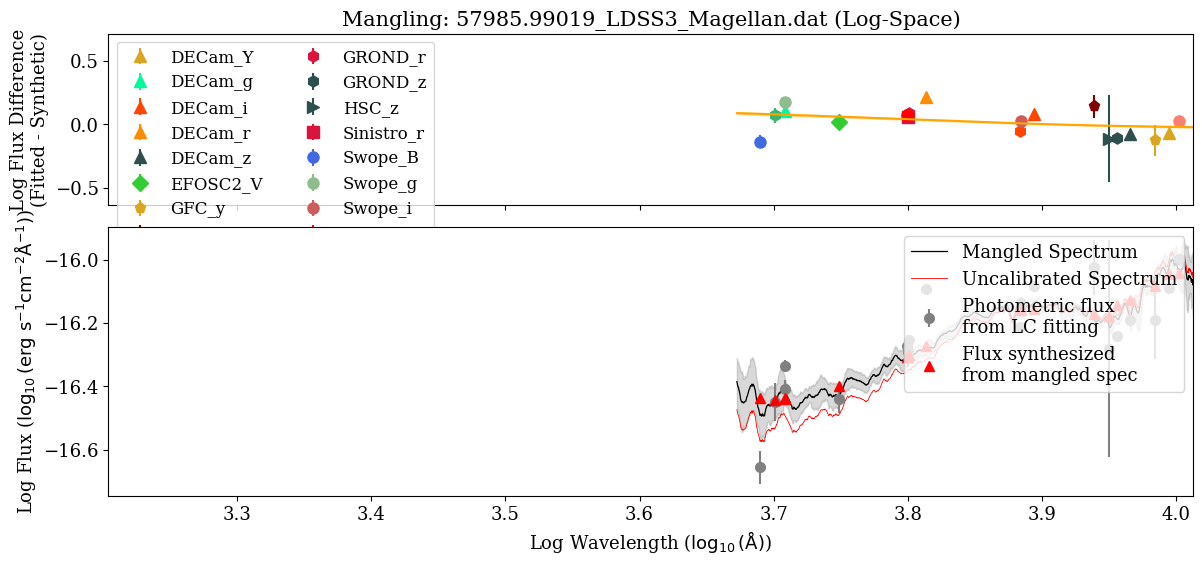

In [14]:
spec= SingleSpectrumClass(snname=snname, spec_file=list_[14], verbose=False)
spec.load_raw_spec()
result = spec.mangle_spectrum_function(show=True)


Checking filter: ANDICAM_K

Checking filter: DECam_Y

Checking filter: DECam_g

Checking filter: DECam_i

Checking filter: DECam_r

Checking filter: DECam_u

Checking filter: DECam_z

Checking filter: EFOSC2_U

Checking filter: EFOSC2_V

Checking filter: FLAMINGOS-2_H

Checking filter: FLAMINGOS-2_J

Checking filter: FLAMINGOS-2_Ks

Checking filter: FORS2_B

Checking filter: FORS2_I

Checking filter: FORS2_R

Checking filter: FORS2_V

Checking filter: FourStar_H

Checking filter: FourStar_J

Checking filter: FourStar_J1

Checking filter: FourStar_Ks

Checking filter: GFC_i

Checking filter: GFC_r

Checking filter: GFC_y

Checking filter: GFC_z

Checking filter: GMOS_g

Checking filter: GMOS_i

Checking filter: GMOS_r

Checking filter: GMOS_z

Checking filter: GROND_H

Checking filter: GROND_J

Checking filter: GROND_K

Checking filter: GROND_g

Checking filter: GROND_i

Checking filter: GROND_r

Checking filter: GROND_z

Checking filter: HAWKI_Ks

Checking filter: HSC_z

Checking filt

/var/folders/0n/xfstb8sn23ldhmmxkvnlgk4c0000gn/T/ipykernel_289/1122813917.py:6: RuntimeWarning: invalid value encountered in scalar divide
  return (integrate.trapezoid(transmission*flux*wls, wls)/\
/var/folders/0n/xfstb8sn23ldhmmxkvnlgk4c0000gn/T/ipykernel_289/3641154487.py:160: RuntimeWarning: invalid value encountered in scalar divide
  raw_phot = integrate.trapezoid(filt_transm_interp_xLambda*cut_raw_spec['flux'], cut_raw_spec['wls'])/\
/var/folders/0n/xfstb8sn23ldhmmxkvnlgk4c0000gn/T/ipykernel_289/3641154487.py:162: RuntimeWarning: invalid value encountered in scalar divide
  raw_phot_err = (integrate.trapezoid((filt_transm_interp_xLambda*cut_raw_spec['fluxerr'])**2,


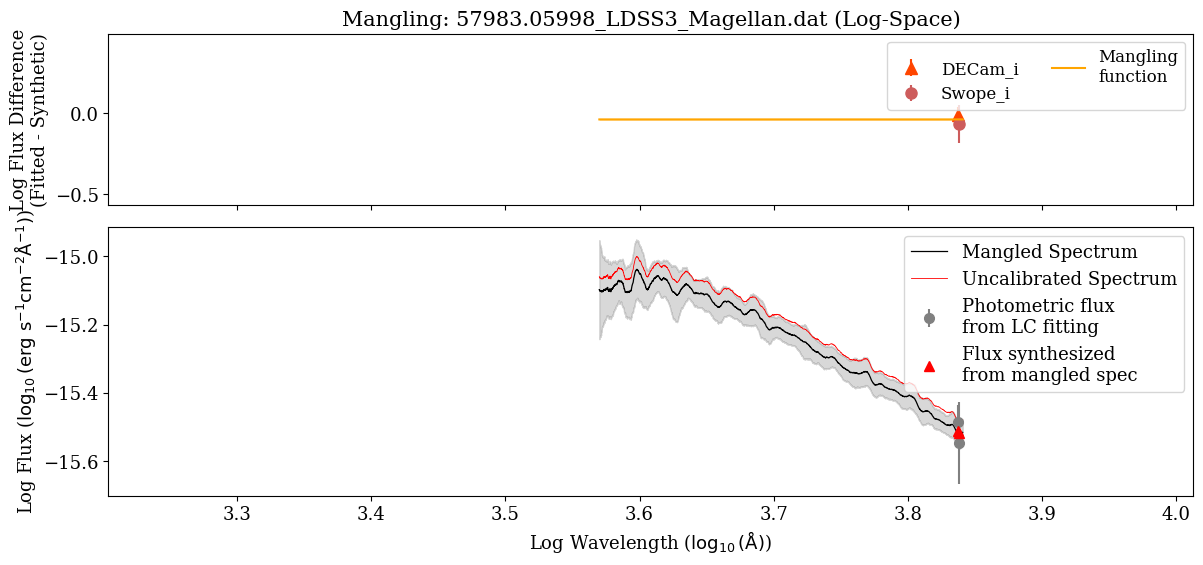

In [15]:
spec = SingleSpectrumClass(snname=snname, spec_file=list_[2], verbose=False)
spec.load_raw_spec()
if spec.phot4mangling is not None and not spec.phot4mangling.empty:
	result = spec.mangle_spectrum_function(show=True)
else:
	print(f"No photometry found for mangling for file: {list_[2]}")

In [ ]:
spec = SingleSpectrumClass(snname=snname, spec_file=list_[0], verbose=False)
spec.load_raw_spec()
if spec.phot4mangling is not None and not spec.phot4mangling.empty:
	result = spec.mangle_spectrum_function(show=True)
else:
	print(f"No photometry found for mangling for file: {list_[0]}")

## Mangle ALL spectra and show the series of mangled specs
#### Results from each single mangling are shown in ./Outputs/SNname/mangled/


Checking filter: ANDICAM_K

Checking filter: DECam_Y

Checking filter: DECam_g

Checking filter: DECam_i

Checking filter: DECam_r

Checking filter: DECam_u

Checking filter: DECam_z

Checking filter: EFOSC2_U

Checking filter: EFOSC2_V

Checking filter: FLAMINGOS-2_H

Checking filter: FLAMINGOS-2_J

Checking filter: FLAMINGOS-2_Ks

Checking filter: FORS2_B

Checking filter: FORS2_I

Checking filter: FORS2_R

Checking filter: FORS2_V

Checking filter: FourStar_H

Checking filter: FourStar_J

Checking filter: FourStar_J1

Checking filter: FourStar_Ks

Checking filter: GFC_i

Checking filter: GFC_r

Checking filter: GFC_y

Checking filter: GFC_z

Checking filter: GMOS_g

Checking filter: GMOS_i

Checking filter: GMOS_r

Checking filter: GMOS_z

Checking filter: GROND_H

Checking filter: GROND_J

Checking filter: GROND_K

Checking filter: GROND_g

Checking filter: GROND_i

Checking filter: GROND_r

Checking filter: GROND_z

Checking filter: HAWKI_Ks

Checking filter: HSC_z

Checking filt

/var/folders/0n/xfstb8sn23ldhmmxkvnlgk4c0000gn/T/ipykernel_289/1122813917.py:6: RuntimeWarning: invalid value encountered in scalar divide
  return (integrate.trapezoid(transmission*flux*wls, wls)/\
/var/folders/0n/xfstb8sn23ldhmmxkvnlgk4c0000gn/T/ipykernel_289/3641154487.py:160: RuntimeWarning: invalid value encountered in scalar divide
  raw_phot = integrate.trapezoid(filt_transm_interp_xLambda*cut_raw_spec['flux'], cut_raw_spec['wls'])/\
/var/folders/0n/xfstb8sn23ldhmmxkvnlgk4c0000gn/T/ipykernel_289/3641154487.py:162: RuntimeWarning: invalid value encountered in scalar divide
  raw_phot_err = (integrate.trapezoid((filt_transm_interp_xLambda*cut_raw_spec['fluxerr'])**2,


True
[(4.00365066, -16.32831297, 0.14682209)
 (4.0036765 , -16.32731653, 0.14476028)
 (4.00370233, -16.3271148 , 0.14366792) ...
 (4.38899451, -16.7630722 , 0.19822637)
 (4.38900515, -16.76222266, 0.19788686)
 (4.38901579, -16.76095145, 0.19853072)]

Checking filter: ANDICAM_K

Checking filter: DECam_Y

Checking filter: DECam_g

Checking filter: DECam_i

Checking filter: DECam_r

Checking filter: DECam_u

Checking filter: DECam_z

Checking filter: EFOSC2_U

Checking filter: EFOSC2_V

Checking filter: FLAMINGOS-2_H

Checking filter: FLAMINGOS-2_J

Checking filter: FLAMINGOS-2_Ks

Checking filter: FORS2_B

Checking filter: FORS2_I

Checking filter: FORS2_R

Checking filter: FORS2_V

Checking filter: FourStar_H

Checking filter: FourStar_J

Checking filter: FourStar_J1

Checking filter: FourStar_Ks

Checking filter: GFC_i

Checking filter: GFC_r

Checking filter: GFC_y

Checking filter: GFC_z

Checking filter: GMOS_g

Checking filter: GMOS_i

Checking filter: GMOS_r

Checking filter: GMOS

/var/folders/0n/xfstb8sn23ldhmmxkvnlgk4c0000gn/T/ipykernel_289/1122813917.py:6: RuntimeWarning: invalid value encountered in scalar divide
  return (integrate.trapezoid(transmission*flux*wls, wls)/\
/var/folders/0n/xfstb8sn23ldhmmxkvnlgk4c0000gn/T/ipykernel_289/3641154487.py:160: RuntimeWarning: invalid value encountered in scalar divide
  raw_phot = integrate.trapezoid(filt_transm_interp_xLambda*cut_raw_spec['flux'], cut_raw_spec['wls'])/\
/var/folders/0n/xfstb8sn23ldhmmxkvnlgk4c0000gn/T/ipykernel_289/3641154487.py:162: RuntimeWarning: invalid value encountered in scalar divide
  raw_phot_err = (integrate.trapezoid((filt_transm_interp_xLambda*cut_raw_spec['fluxerr'])**2,



Checking filter: ANDICAM_K

Checking filter: DECam_Y

Checking filter: DECam_g

Checking filter: DECam_i

Checking filter: DECam_r

Checking filter: DECam_u

Checking filter: DECam_z

Checking filter: EFOSC2_U

Checking filter: EFOSC2_V

Checking filter: FLAMINGOS-2_H

Checking filter: FLAMINGOS-2_J

Checking filter: FLAMINGOS-2_Ks

Checking filter: FORS2_B

Checking filter: FORS2_I

Checking filter: FORS2_R

Checking filter: FORS2_V

Checking filter: FourStar_H

Checking filter: FourStar_J

Checking filter: FourStar_J1

Checking filter: FourStar_Ks

Checking filter: GFC_i

Checking filter: GFC_r

Checking filter: GFC_y

Checking filter: GFC_z

Checking filter: GMOS_g

Checking filter: GMOS_i

Checking filter: GMOS_r

Checking filter: GMOS_z

Checking filter: GROND_H

Checking filter: GROND_J

Checking filter: GROND_K

Checking filter: GROND_g

Checking filter: GROND_i

Checking filter: GROND_r

Checking filter: GROND_z

Checking filter: HAWKI_Ks

Checking filter: HSC_z

Checking filt

...

/var/folders/0n/xfstb8sn23ldhmmxkvnlgk4c0000gn/T/ipykernel_289/1122813917.py:6: RuntimeWarning: invalid value encountered in scalar divide
  return (integrate.trapezoid(transmission*flux*wls, wls)/\
/var/folders/0n/xfstb8sn23ldhmmxkvnlgk4c0000gn/T/ipykernel_289/3641154487.py:160: RuntimeWarning: invalid value encountered in scalar divide
  raw_phot = integrate.trapezoid(filt_transm_interp_xLambda*cut_raw_spec['flux'], cut_raw_spec['wls'])/\
/var/folders/0n/xfstb8sn23ldhmmxkvnlgk4c0000gn/T/ipykernel_289/3641154487.py:162: RuntimeWarning: invalid value encountered in scalar divide
  raw_phot_err = (integrate.trapezoid((filt_transm_interp_xLambda*cut_raw_spec['fluxerr'])**2,



Checking filter: ANDICAM_K

Checking filter: DECam_Y

Checking filter: DECam_g

Checking filter: DECam_i

Checking filter: DECam_r

Checking filter: DECam_u

Checking filter: DECam_z

Checking filter: EFOSC2_U

Checking filter: EFOSC2_V

Checking filter: FLAMINGOS-2_H

Checking filter: FLAMINGOS-2_J

Checking filter: FLAMINGOS-2_Ks

Checking filter: FORS2_B

Checking filter: FORS2_I

Checking filter: FORS2_R

Checking filter: FORS2_V

Checking filter: FourStar_H

Checking filter: FourStar_J

Checking filter: FourStar_J1

Checking filter: FourStar_Ks

Checking filter: GFC_i

Checking filter: GFC_r

Checking filter: GFC_y

Checking filter: GFC_z

Checking filter: GMOS_g

Checking filter: GMOS_i

Checking filter: GMOS_r

Checking filter: GMOS_z

Checking filter: GROND_H

Checking filter: GROND_J

Checking filter: GROND_K

Checking filter: GROND_g

Checking filter: GROND_i

Checking filter: GROND_r

Checking filter: GROND_z

Checking filter: HAWKI_Ks

Checking filter: HSC_z

Checking filt

/var/folders/0n/xfstb8sn23ldhmmxkvnlgk4c0000gn/T/ipykernel_289/1122813917.py:6: RuntimeWarning: invalid value encountered in scalar divide
  return (integrate.trapezoid(transmission*flux*wls, wls)/\
/var/folders/0n/xfstb8sn23ldhmmxkvnlgk4c0000gn/T/ipykernel_289/3641154487.py:160: RuntimeWarning: invalid value encountered in scalar divide
  raw_phot = integrate.trapezoid(filt_transm_interp_xLambda*cut_raw_spec['flux'], cut_raw_spec['wls'])/\
/var/folders/0n/xfstb8sn23ldhmmxkvnlgk4c0000gn/T/ipykernel_289/3641154487.py:162: RuntimeWarning: invalid value encountered in scalar divide
  raw_phot_err = (integrate.trapezoid((filt_transm_interp_xLambda*cut_raw_spec['fluxerr'])**2,



Checking filter: ANDICAM_K

Checking filter: DECam_Y

Checking filter: DECam_g

Checking filter: DECam_i

Checking filter: DECam_r

Checking filter: DECam_u

Checking filter: DECam_z

Checking filter: EFOSC2_U

Checking filter: EFOSC2_V

Checking filter: FLAMINGOS-2_H

Checking filter: FLAMINGOS-2_J

Checking filter: FLAMINGOS-2_Ks

Checking filter: FORS2_B

Checking filter: FORS2_I

Checking filter: FORS2_R

Checking filter: FORS2_V

Checking filter: FourStar_H

Checking filter: FourStar_J

Checking filter: FourStar_J1

Checking filter: FourStar_Ks

Checking filter: GFC_i

Checking filter: GFC_r

Checking filter: GFC_y

Checking filter: GFC_z

Checking filter: GMOS_g

Checking filter: GMOS_i

Checking filter: GMOS_r

Checking filter: GMOS_z

Checking filter: GROND_H

Checking filter: GROND_J

Checking filter: GROND_K

Checking filter: GROND_g

Checking filter: GROND_i

Checking filter: GROND_r

Checking filter: GROND_z

Checking filter: HAWKI_Ks

Checking filter: HSC_z

Checking filt

/var/folders/0n/xfstb8sn23ldhmmxkvnlgk4c0000gn/T/ipykernel_289/1122813917.py:6: RuntimeWarning: invalid value encountered in scalar divide
  return (integrate.trapezoid(transmission*flux*wls, wls)/\
/var/folders/0n/xfstb8sn23ldhmmxkvnlgk4c0000gn/T/ipykernel_289/3641154487.py:160: RuntimeWarning: invalid value encountered in scalar divide
  raw_phot = integrate.trapezoid(filt_transm_interp_xLambda*cut_raw_spec['flux'], cut_raw_spec['wls'])/\
/var/folders/0n/xfstb8sn23ldhmmxkvnlgk4c0000gn/T/ipykernel_289/3641154487.py:162: RuntimeWarning: invalid value encountered in scalar divide
  raw_phot_err = (integrate.trapezoid((filt_transm_interp_xLambda*cut_raw_spec['fluxerr'])**2,


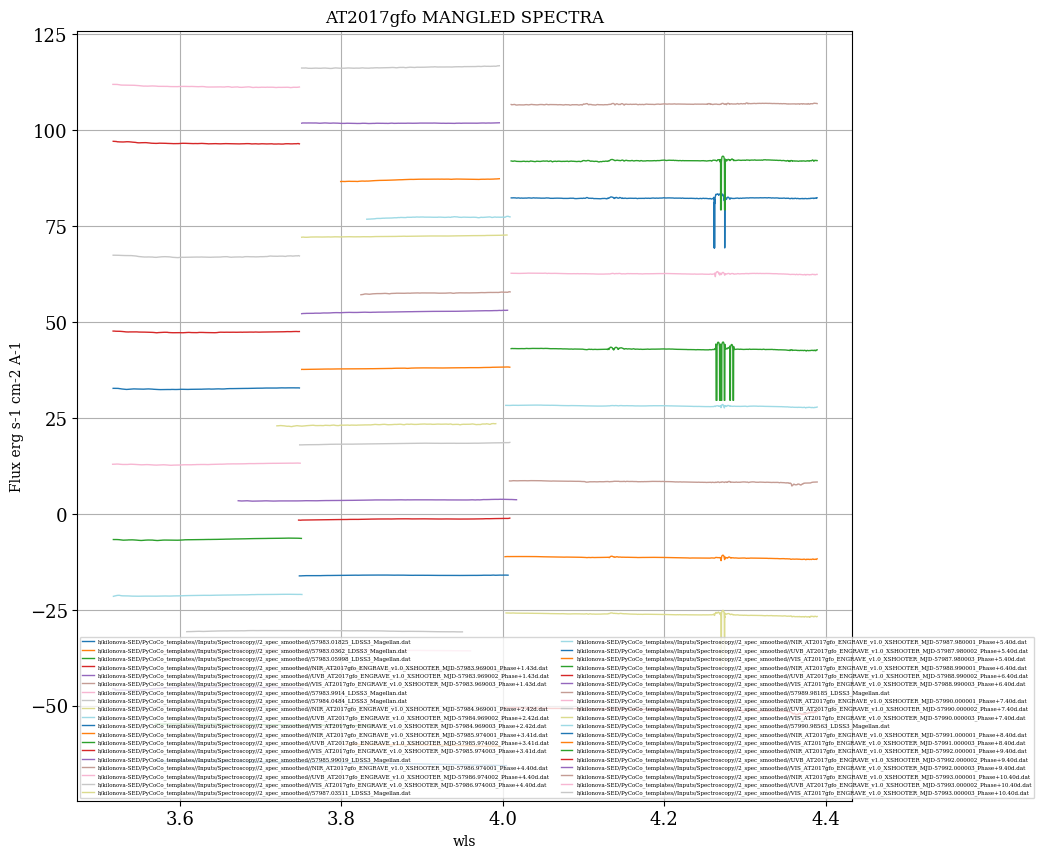


All spectra were successfully mangled.


In [16]:
plot_all_mangledspecs(spec_class)